In [3]:
import pandas as pd
df = pd.read_csv("sales.csv")
df

# EDA

# DATA CLEANING
df.isnull().sum()

# Data transformation
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   400 non-null    int64 
 1   CompPrice    400 non-null    int64 
 2   Income       400 non-null    int64 
 3   Advertising  400 non-null    int64 
 4   Population   400 non-null    int64 
 5   Price        400 non-null    int64 
 6   ShelveLoc    400 non-null    object
 7   Age          400 non-null    int64 
 8   Education    400 non-null    int64 
 9   Urban        400 non-null    object
 10  US           400 non-null    object
 11  high         400 non-null    object
dtypes: int64(8), object(4)
memory usage: 37.6+ KB


In [4]:
#---------------------------------------------------------
x_cont= df[df.columns[[1,2,3,4,5,7]]]

from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(x_cont)
SS_X = pd.DataFrame(SS_X)
SS_X.columns = list(df.columns[[1,2,3,4,5,7]])
SS_X

,CompPrice,Income,Advertising,Population,Price,Age
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000
...,...,...,...,...,...,...
395,0.850455,1.407551,1.560513,-0.420131,0.516132,-1.256023
396,0.915749,-1.633482,-0.547271,-1.547909,0.177823,0.103677
397,2.417512,-1.526151,0.807733,0.700853,1.827078,-0.823391
398,-1.630719,0.370022,0.054953,0.130170,-0.879391,-0.205346


In [5]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df["ShelveLoc"] = LE.fit_transform(df["ShelveLoc"])
df["Urban"]     = LE.fit_transform(df["Urban"])
df["US"]        = LE.fit_transform(df["US"])
df["high"]      = LE.fit_transform(df["high"])
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,0,42,17,1,1,1
1,2,111,48,16,260,83,1,65,10,1,1,1
2,3,113,35,10,269,80,2,59,12,1,1,1
3,4,117,100,4,466,97,2,55,14,1,1,0
4,5,141,64,3,340,128,0,38,13,1,0,0


In [6]:
#---------------------------------------------------------

#df.info()
df_cat = df[df.columns[[6,8,9,10,11]]]
df_cat


,ShelveLoc,Education,Urban,US,high
0,0,17,1,1,1
1,1,10,1,1,1
2,2,12,1,1,1
3,2,14,1,1,0
4,0,13,1,0,0
...,...,...,...,...,...
395,1,14,1,1,1
396,2,11,0,1,0
397,2,18,1,1,0
398,0,12,1,1,0


In [7]:
df_new = pd.concat([SS_X,df_cat],axis=1)
df_new

,CompPrice,Income,Advertising,Population,Price,Age,ShelveLoc,Education,Urban,US,high
0,0.850455,0.155361,0.657177,0.075819,0.177823,-0.699782,0,17,1,1,1
1,-0.912484,-0.739060,1.409957,-0.032882,-1.386854,0.721723,1,10,1,1,1
2,-0.781896,-1.204159,0.506621,0.028262,-1.513719,0.350895,2,12,1,1,1
3,-0.520720,1.121336,-0.396715,1.366649,-0.794814,0.103677,2,14,1,1,0
4,1.046337,-0.166631,-0.547271,0.510625,0.516132,-0.947000,0,13,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
395,0.850455,1.407551,1.560513,-0.420131,0.516132,-1.256023,1,14,1,1,1
396,0.915749,-1.633482,-0.547271,-1.547909,0.177823,0.103677,2,11,0,1,0
397,2.417512,-1.526151,0.807733,0.700853,1.827078,-0.823391,2,18,1,1,0
398,-1.630719,0.370022,0.054953,0.130170,-0.879391,-0.205346,0,12,1,1,0


In [8]:
# data partition
Y = df_new["high"]
X = df_new.drop(df_new[['high']],axis=1)

print(Y.shape)
print(X.shape)


(400,)
(400, 10)


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.3)

In [12]:
#---------------------------------------------------------1
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion='entropy',max_depth=6) # entropy
DT.fit(X_train,Y_train)

Y_pred_train = DT.predict(X_train)
Y_pred_test = DT.predict(X_test)

from sklearn.metrics import accuracy_score, log_loss
training_accuracy  = accuracy_score(Y_train,Y_pred_train)
test_accuracy  = accuracy_score(Y_test,Y_pred_test)

training_loss  = log_loss(Y_train,Y_pred_train)
test_loss  = log_loss(Y_test,Y_pred_test)

import numpy as np
print("trianing accuracy:", np.round(training_accuracy,2))
print("test accuracy:", np.round(test_accuracy,2))
print("trianing loss:", np.round(training_loss,2))
print("test loss:", np.round(test_loss,2))


trianing accuracy: 0.87
test accuracy: 0.76
trianing loss: 4.76
test loss: 8.71


In [ ]:
#=============================================================
# shuffle split
#=============================================================

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',max_depth=6)

# Set up ShuffleSplit cross-validator
from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split = ShuffleSplit(n_splits=200, test_size=0.3, random_state=42)

# Perform cross-validation and collect both train and test scores
cv_results = cross_validate(model, X, Y, cv=shuffle_split, scoring='accuracy', return_train_score=True)

# Extract train and test scores
train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

# Show individual scores and their means
print("cross validation: Train accuracy:" , np.round(train_scores.mean(),2))
print("cross validation: test accuracy:" , np.round(test_scores.mean(),2))


cross validation: Train accuracy: 0.93
cross validation: test accuracy: 0.72


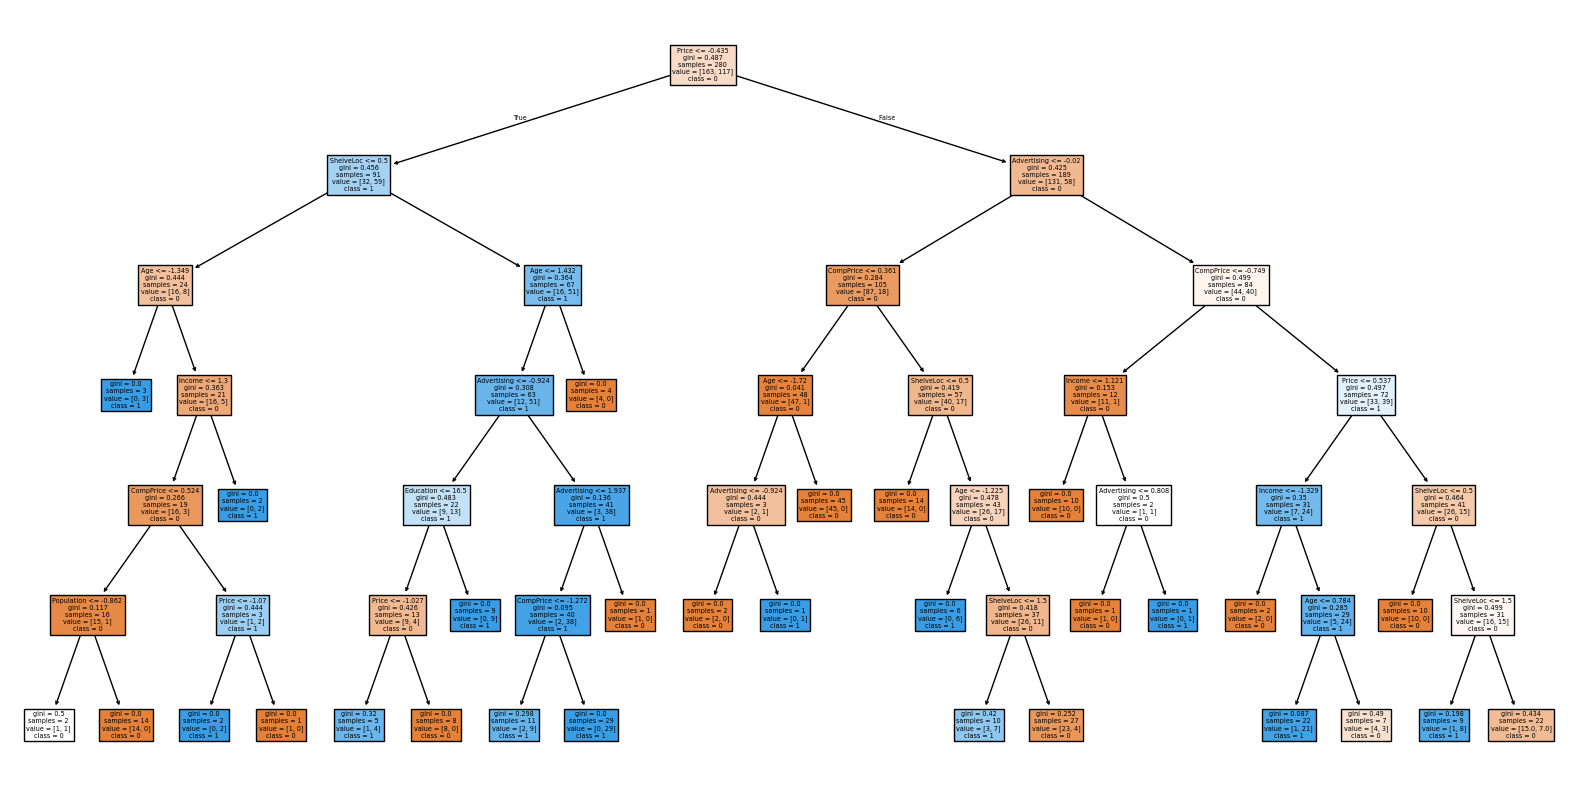

In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    DT,  # Get the first fitted estimator from cross-validation
    filled=True,
    feature_names=X.columns,
    class_names=['0', '1'],
)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
n_nodes = DT.tree_.node_count
depth = DT.tree_.max_depth

print(f"Number of nodes: {n_nodes}")
print(f"Depth of the tree: {depth}")


Number of nodes: 57
Depth of the tree: 6
